<h1 align="center" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">
<font color="#EF4056">
Transformers in JAX &mdash; Part 2: Self-Attention at Digikala
</font>
</h1>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">
<font color="#EF4056">
Part 1 &mdash; The Backstory
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
The bus across town drops Nika in front of the <b>Digikala</b> tower on a bright Sunday morning, a borrowed badge clipped to her bag and a laptop full of half-finished Snapp experiments. Her platform team has lent her out for a two-week cross-team sprint, because the search group at Digikala wants the same in-house language-model expertise that Nika has been building since she wrote her first character tokenizer. The problem on the table is deceptively ordinary, namely the little box at the top of the marketplace where millions of people type the first few letters of what they want to buy. Today that box completes a query by matching prefixes, which means it has no idea that the word <i>case</i> after <i>phone</i> means something very different from <i>case</i> after <i>court</i>. The search lead, Sahar, wants completions that read the whole context and not just the last word, and she is convinced the answer is the attention mechanism that powers every modern GPT. Nika has already turned text into clean integer tensors in her previous notebook, so tonight she finally gets to build the part that made Transformers famous. She opens a fresh notebook, pours a glass of tea, and this is exactly where you join her.
</font>
</p>

<div style="text-align:center;">
    <img src="images/Digikala-logo.png" style="width:100%;">
</div>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">
<font color="#EF4056">
Part 2 &mdash; The Mission Brief
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
Sahar pulls a chair next to Nika and explains the goal in a single sentence, namely a context-aware autocomplete that weighs every earlier character when it guesses the next one. To make the idea concrete she reaches for an analogy that Nika will never forget, describing attention as a soft dictionary lookup. In an ordinary dictionary you hold a key, you find the one matching entry, and you read its value, but in attention every position emits a <b>query</b> that is compared against the <b>key</b> of every position, and instead of picking a single match you blend all the <b>values</b> in proportion to how well the keys matched. That blending is what lets the word <i>case</i> quietly pull meaning from <i>phone</i> three tokens earlier, and it is the entire reason Transformers can model long-range context. Over the next hour Nika will implement scaled dot-product attention with her own hands, add the causal mask that forbids any position from peeking at the future, and finally give the model a sense of order through sinusoidal positional encodings. Sahar reminds her that the search team's evaluation harness checks numbers, not prose, so every tensor must come out exactly right. By the end of the notebook Nika will hold a working single-head attention layer, the precise building block that the next notebook stacks into multi-head attention and a full Transformer block. Each part of this five-part lab builds directly on the one before it, marching step by step from the tokenizer of Part 1 toward the small trained MiniGPT that closes the series.
</font>
</p>

<div style="text-align:center;">
    <img src="images/digikala1.png" style="width:100%;">
</div>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">0. The architecture at a glance</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Before writing any code, it helps to see where tonight's work sits inside a full Transformer. The diagram below shows the original encoder&ndash;decoder architecture; a GPT keeps only the right-hand <b>masked self-attention</b> column, and the single block you are about to build by hand is the very first thing inside it. Everything else in the lab &mdash; multi-head attention, the feed-forward network, the residual stream &mdash; wraps around this one operation.
</p>
</p>

<div style="text-align:center;">
    <img src="images/transformer_full_architecture.png" width="600">
    <p style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:small;color:#666;margin-top:6px;"><i>GPT uses the masked self-attention (decoder) column. Everything you build tonight lives inside that one block.</i></p>
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">Learning note &mdash; Why attention? Mixing information between tokens</h4>
<p style="line-height:180%; font-size:medium;">
After tokenization and embedding, each token in a sequence is just an isolated vector that knows nothing about its neighbours. Yet the meaning of a word depends almost entirely on its context, so a useful language model must let tokens <b>exchange information</b> with one another before predicting anything. <b>Self-attention</b> is the mechanism that does exactly this: for every position it produces a new vector that is a weighted blend of the vectors at other positions, where the weights are computed from the content itself. Unlike a convolution, which can only mix neighbours inside a small fixed window, attention can connect position one to position one thousand in a single step, which is why it captures long-range dependencies so well. Unlike a recurrent network, which must process tokens one after another, attention compares all pairs of positions at once and is therefore highly parallel, a perfect match for the accelerators that <code>jax.jit</code> targets. The price is a cost that grows with the square of the sequence length, because every position looks at every other position. Understanding this mixing operation is the single most important idea in the whole lab.
</p>

<div style="text-align:center;">
    <img src="images/gpt_logo.svg" style="width:30%;">
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">Learning note &mdash; Query, Key, and Value: a soft dictionary lookup</h4>
<p style="line-height:180%; font-size:medium;">
The cleanest way to understand attention is the soft-dictionary analogy that Sahar gave Nika. From each token's embedding we compute three different vectors with three learned projections: a <b>query</b> <code>q</code> that represents what this position is looking for, a <b>key</b> <code>k</code> that advertises what each position offers, and a <b>value</b> <code>v</code> that carries the information each position will contribute. To decide how much position <i>i</i> should attend to position <i>j</i>, we take the dot product of <code>q<sub>i</sub></code> with <code>k<sub>j</sub></code>: a large dot product means the query and key point in similar directions and are therefore a good match. These match scores are turned into non-negative weights that sum to one with a <b>softmax</b>, and the output for position <i>i</i> is the weighted sum of all the <b>values</b> using those weights. A hard dictionary would put all of its weight on a single key; attention is soft because the softmax spreads the weight smoothly across every key in proportion to how well it matched. The same three projections, applied to the same input, are what make this <i>self</i>-attention.
</p>

<div style="text-align:center;">
    <img src="images/digikala2.png" style="width:100%;">
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">Learning note &mdash; Scaled dot-product attention, and why we divide by &radic;d_head</h4>
<p style="line-height:180%; font-size:medium;">
Putting the pieces together gives the famous formula Attention(Q, K, V) = softmax(Q K<sup>T</sup> / &radic;d<sub>head</sub>) V. The matrix <code>Q K<sup>T</sup></code> holds the dot product of every query with every key, so its entry (i, j) is the raw match score between positions i and j; the softmax along each row turns one row of scores into a probability distribution over the keys, and multiplying by <code>V</code> produces the blended output. The only subtle part is the division by the square root of <code>d<sub>head</sub></code>, the dimension of each query and key vector. When <code>q</code> and <code>k</code> have independent unit-variance entries, their dot product is a sum of <code>d<sub>head</sub></code> such products and therefore has variance proportional to <code>d<sub>head</sub></code>, so for large dimensions the raw scores grow large in magnitude. Feeding large scores into a softmax pushes it into a near one-hot regime where almost all the weight lands on a single key and the gradients with respect to the other scores vanish, which cripples learning. Dividing by <code>&radic;d<sub>head</sub></code> rescales the scores back to roughly unit variance, keeping the softmax in a healthy, trainable range. We will verify this variance argument empirically with a chart.
</p>

<div style="text-align:center;">
    <img src="images/softmax.png" width="300">
    <p style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:small;color:#666;margin-top:6px;"><i>The softmax along each row of the score matrix turns raw match scores into attention weights that sum to one.</i></p>
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">Learning note &mdash; The causal mask: no peeking at the future</h4>
<p style="line-height:180%; font-size:medium;">
A GPT is trained to predict the next token from the tokens that came before it, so when the model is processing position <i>t</i> it must be forbidden from looking at positions <i>t+1, t+2, &hellip;</i> that lie in the future. Without this rule the task would be trivial and useless, because the model could simply read the answer it is supposed to predict. We enforce it with a <b>causal mask</b>, a lower-triangular pattern of allowed positions: position <i>i</i> may attend to position <i>j</i> only when <code>j &le; i</code>. In code the mask is a boolean matrix, and we apply it by setting the score of every forbidden pair to a very large negative number <i>before</i> the softmax. After the softmax those entries become effectively zero, so no probability mass ever flows from the future into the present. This single trick is what makes the attention <b>causal</b>, also called masked self-attention, and it is the only structural difference between a GPT decoder block and the encoder block of the original Transformer. When you visualize the attention weights as a heatmap, the causal mask shows up as a clean dark upper triangle.
</p>

<div style="text-align:center;">
    <img src="images/digikala3.png" style="width:100%;">
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">Learning note &mdash; Positional encodings: giving the model a sense of order</h4>
<p style="line-height:180%; font-size:medium;">
Attention as described so far has a surprising blind spot: it is <b>permutation-equivariant</b>, meaning that if you shuffle the input tokens the outputs are shuffled the same way, because nothing in the dot-product computation depends on <i>where</i> a token sits. Yet word order obviously carries meaning, since <i>dog bites man</i> is not <i>man bites dog</i>, so we must inject position information explicitly. The original Transformer does this with <b>sinusoidal positional encodings</b>: for each position we build a vector of sines and cosines whose frequencies vary smoothly across the embedding dimensions, using even dimensions for sines and odd dimensions for cosines. Concretely the angle for position <i>pos</i> and dimension <i>i</i> is <code>pos / 10000<sup>(2&lfloor;i/2&rfloor;/d)</sup></code>, which gives high-frequency oscillations in the early dimensions and very slow ones later. This scheme is elegant because the encoding for any position is a fixed deterministic vector that needs no training, its values stay bounded in the range from &minus;1 to 1, and because of trigonometric identities a fixed offset between two positions corresponds to a linear transform of their encodings, which makes relative distances easy for the model to recover. We add this positional vector to the token embedding so that each input carries both <i>what</i> the token is and <i>where</i> it sits.
</p>

<div style="text-align:center;">
    <img src="images/digikala4.png" style="width:100%;">
</div>

In [1]:
import os, time, math, pickle, urllib.request
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

print("JAX", jax.__version__, "| Flax", nn.__version__ if hasattr(nn,"__version__") else "", "| devices:", jax.devices())

JAX 0.10.2 | Flax  | devices: [CpuDevice(id=0)]


<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">Learning note &mdash; Continuing from Part 1</h4>
<p style="line-height:180%; font-size:medium;">
The setup cell below is not new work. The character <b>tokenizer</b>, the train/validation <b>batching</b>, and the numerically <b>stable softmax</b> shown there are exactly the pieces Nika built by hand in Part 1 at Snapp, brought forward here unchanged so that this part can focus entirely on attention. In the same spirit, the single-head self-attention you assemble in this notebook is not a throwaway exercise: it is reused directly in Part 3, where it is replicated into multi-head attention and wrapped in a Transformer block, and it keeps running underneath everything in the parts that follow, all the way up to the small trained MiniGPT that ends the lab.
</p>

In [2]:
# Setup (given) — solved code from Part 1.

def load_tiny_shakespeare():
    for path in ("data/tiny_shakespeare.txt", "tiny_shakespeare.txt", "../data/tiny_shakespeare.txt"):
        if os.path.exists(path):
            return open(path, encoding="utf-8").read()
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(url, "data/tiny_shakespeare.txt")
    return open("data/tiny_shakespeare.txt", encoding="utf-8").read()

text = load_tiny_shakespeare()
print(f"Corpus length: {len(text):,} characters")

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join(itos[int(i)] for i in ids)

data = np.array(encode(text), dtype=np.int32)

n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"train: {len(train_data):,} tokens | val: {len(val_data):,} tokens")

def get_batch(key, split, batch_size, block_size):
    source = train_data if split == "train" else val_data
    ix = jax.random.randint(key, (batch_size,), 0, len(source) - block_size - 1)
    ix = np.asarray(ix)
    x = np.stack([source[i:i + block_size] for i in ix])
    y = np.stack([source[i + 1:i + 1 + block_size] for i in ix])
    return jnp.asarray(x), jnp.asarray(y)

def stable_softmax(z, axis=-1):
    z = z - jnp.max(z, axis=axis, keepdims=True)
    ez = jnp.exp(z)
    return ez / jnp.sum(ez, axis=axis, keepdims=True)

print('recap ready, vocab_size =', vocab_size)

Corpus length: 1,115,394 characters
train: 1,003,854 tokens | val: 111,540 tokens
recap ready, vocab_size = 65


<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">1. Scaled dot-product attention and the causal mask</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
This is the heart of the notebook. Implement <code>scaled_dot_product_attention(q, k, v, mask=None)</code> following the formula softmax(q k<sup>T</sup> / &radic;d<sub>head</sub>) v, and implement <code>causal_mask(T)</code> that returns a lower-triangular boolean matrix of shape <code>(T, T)</code>. Read <code>d_head</code> from the last axis of <code>q</code>, build the scores with a batched matrix multiply against the transpose of <code>k</code>, divide by <code>jnp.sqrt(d_head)</code>, and when a mask is supplied replace every forbidden score with a large negative number using <code>jnp.where</code> <i>before</i> the softmax. Return both the output and the attention weights so we can plot them. You may use <code>jax.nn.softmax</code> here for the final normalization.
</p>
</p>

In [3]:
def scaled_dot_product_attention(q, k, v, mask=None):
    # Calculate the size of the last axis of q
    d_head = q.shape[-1]
    
    # Compute scores: (q @ k transposed on its last two axes) / sqrt(d_head)
    scores = (q @ k.swapaxes(-2, -1)) / jnp.sqrt(d_head)
    
    if mask is not None:
        # Where the mask is False, set the score to a large negative number (-1e9)
        scores = jnp.where(mask, scores, -1e9)
        
    # Compute attention weights using softmax
    attn = jax.nn.softmax(scores, axis=-1)
    
    # Compute the final output by multiplying attention weights with v
    out = attn @ v
    
    return out, attn


def causal_mask(T):
    # Return a lower-triangular boolean matrix of shape (T, T)
    # True on and below the diagonal
    return jnp.tril(jnp.ones((T, T), dtype=bool))

In [4]:
# Self-check: rows of the attention matrix are probabilities, and the mask zeros the future.
_k = jax.random.PRNGKey(0)
q = jax.random.normal(jax.random.fold_in(_k, 11), (5, 8))
k = jax.random.normal(jax.random.fold_in(_k, 12), (5, 8))
v = jax.random.normal(jax.random.fold_in(_k, 13), (5, 8))

m = causal_mask(5)
assert m.shape == (5, 5) and m.dtype == jnp.bool_
assert bool(m[0, 0]) and not bool(m[0, 4]) and bool(m[4, 0])

out_nomask, attn_nomask = scaled_dot_product_attention(q, k, v)
out_mask, attn_mask = scaled_dot_product_attention(q, k, v, m)
assert out_mask.shape == (5, 8) and attn_mask.shape == (5, 5)
assert jnp.allclose(attn_nomask.sum(axis=-1), 1.0, atol=1e-6)
assert jnp.allclose(attn_mask.sum(axis=-1), 1.0, atol=1e-6)
assert float(jnp.max(jnp.triu(attn_mask, k=1))) < 1e-6   # nothing above the diagonal
print("OK: attention rows sum to 1; the causal mask zeros every future position")

OK: attention rows sum to 1; the causal mask zeros every future position


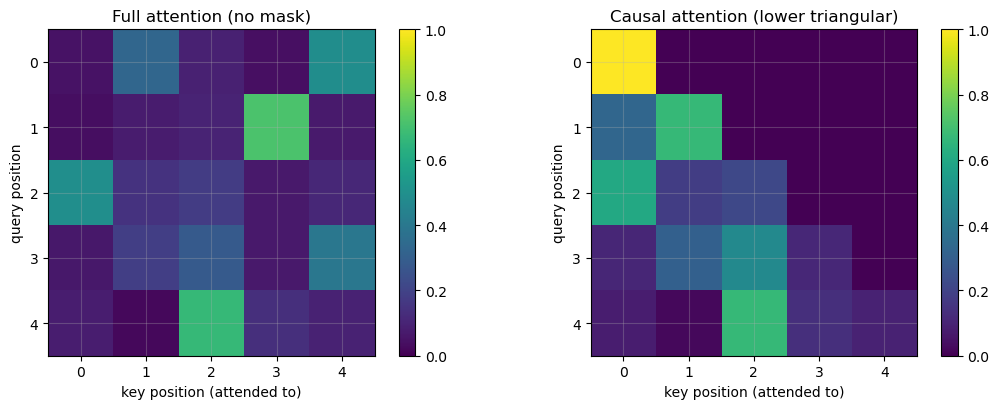

In [5]:
# CHART 1 — attention heatmaps, with and without the causal mask, side by side.
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
im0 = ax[0].imshow(np.array(attn_nomask), cmap="viridis", vmin=0, vmax=1)
ax[0].set_title("Full attention (no mask)")
ax[0].set_xlabel("key position (attended to)"); ax[0].set_ylabel("query position")
fig.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(np.array(attn_mask), cmap="viridis", vmin=0, vmax=1)
ax[1].set_title("Causal attention (lower triangular)")
ax[1].set_xlabel("key position (attended to)"); ax[1].set_ylabel("query position")
fig.colorbar(im1, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">2. Why we divide by &radic;d_head</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Let us prove the scaling argument from the learning note with a quick experiment. For several head dimensions we draw many random query/key pairs, then measure the variance of the raw dot product <code>q&middot;k</code> and of the scaled dot product <code>q&middot;k / &radic;d</code>. The raw variance should grow roughly linearly with <code>d</code>, while the scaled variance should stay close to one regardless of <code>d</code>, which is exactly why the softmax stays well-behaved.
</p>
</p>

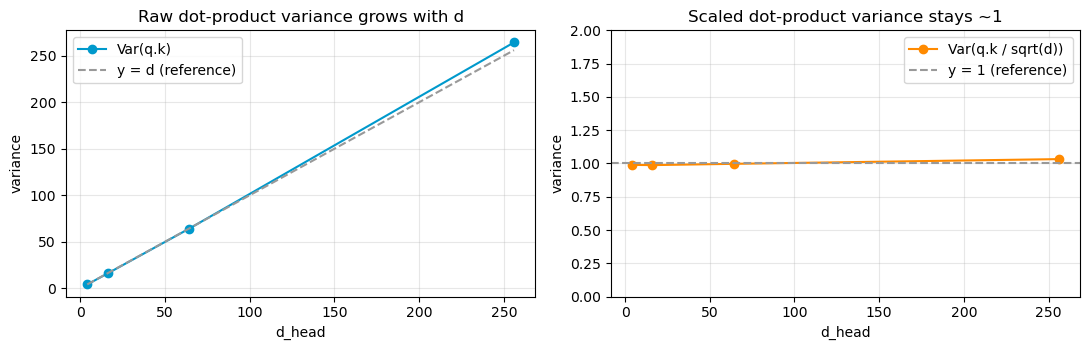

raw variances : [4.0, 15.8, 63.8, 264.3]
scaled vars   : [0.989, 0.987, 0.997, 1.033]


In [6]:
# CHART 2 — variance of q.k grows ~d, but q.k / sqrt(d) stays ~1.
dims = [4, 16, 64, 256]
raw_var, scaled_var = [], []
key = jax.random.PRNGKey(2)
for d in dims:
    key, k1, k2 = jax.random.split(key, 3)
    qd = jax.random.normal(k1, (20000, d))
    kd = jax.random.normal(k2, (20000, d))
    dots = jnp.sum(qd * kd, axis=-1)           # one dot product per row
    raw_var.append(float(jnp.var(dots)))
    scaled_var.append(float(jnp.var(dots / jnp.sqrt(d))))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(dims, raw_var, "-o", color="#0099cc", label="Var(q.k)")
ax[0].plot(dims, dims, "--", color="#999", label="y = d (reference)")
ax[0].set_title("Raw dot-product variance grows with d")
ax[0].set_xlabel("d_head"); ax[0].set_ylabel("variance"); ax[0].legend()
ax[1].plot(dims, scaled_var, "-o", color="#ff8a00", label="Var(q.k / sqrt(d))")
ax[1].axhline(1.0, ls="--", color="#999", label="y = 1 (reference)")
ax[1].set_title("Scaled dot-product variance stays ~1")
ax[1].set_xlabel("d_head"); ax[1].set_ylabel("variance"); ax[1].set_ylim(0, 2); ax[1].legend()
plt.tight_layout(); plt.show()
print("raw variances :", [round(x, 1) for x in raw_var])
print("scaled vars   :", [round(x, 3) for x in scaled_var])

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">Learning note &mdash; Implementation note &mdash; building the positional encoding</h4>
<p style="line-height:180%; font-size:medium;">
You will now build the sinusoidal positional-encoding table from the formula in the learning note. For a sequence of length <code>T</code> and model dimension <code>d</code>, the result is a <code>(T, d)</code> matrix whose row <i>pos</i> is the encoding for that position. The angle for position <i>pos</i> and dimension <i>i</i> is <code>pos / 10000<sup>(2&lfloor;i/2&rfloor;/d)</sup></code>; even dimensions take the sine of the angle and odd dimensions take the cosine. Because the pairing of <code>2&lfloor;i/2&rfloor;</code> ties dimensions together two at a time, neighbouring sine/cosine pairs share a frequency, which is the property that makes relative positions linearly recoverable.
</p>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">3. Positional encoding</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Implement <code>positional_encoding(T, d)</code> returning a <code>(T, d)</code> array. Build a column vector of positions <code>pos</code> and a row vector of dimension indices <code>i</code>, form <code>angle_rates = 1 / 10000<sup>(2(i // 2) / d)</sup></code>, multiply to get the per-position angles, and finally select <code>sin</code> for even <code>i</code> and <code>cos</code> for odd <code>i</code> with <code>jnp.where</code>. Do not loop over positions; use broadcasting so the same code runs on any length.
</p>
</p>

<div style="text-align:center;">
    <img src="images/digikala5.png" style="width:100%;">
</div>

In [7]:
def positional_encoding(T, d):
    # Create a column vector of positions
    pos = jnp.arange(T)[:, None]
    
    # Create a row vector of dimension indices
    i = jnp.arange(d)[None, :]
    
    # Compute angle rates based on the formula
    angle_rates = 1.0 / (10000 ** ((2 * (i // 2)) / d))
    
    # Compute angles by multiplying positions and angle rates
    angles = pos * angle_rates
    
    # Apply sine on even dimensions and cosine on odd dimensions
    return jnp.where(i % 2 == 0, jnp.sin(angles), jnp.cos(angles))

In [8]:
# Self-check: shape is (T, d) and every value lies in [-1, 1].
pe = positional_encoding(32, 16)
assert pe.shape == (32, 16)
assert float(jnp.max(jnp.abs(pe))) <= 1.0 + 1e-6
print("OK: positional_encoding has shape", pe.shape, "and |values| <= 1")

OK: positional_encoding has shape (32, 16) and |values| <= 1


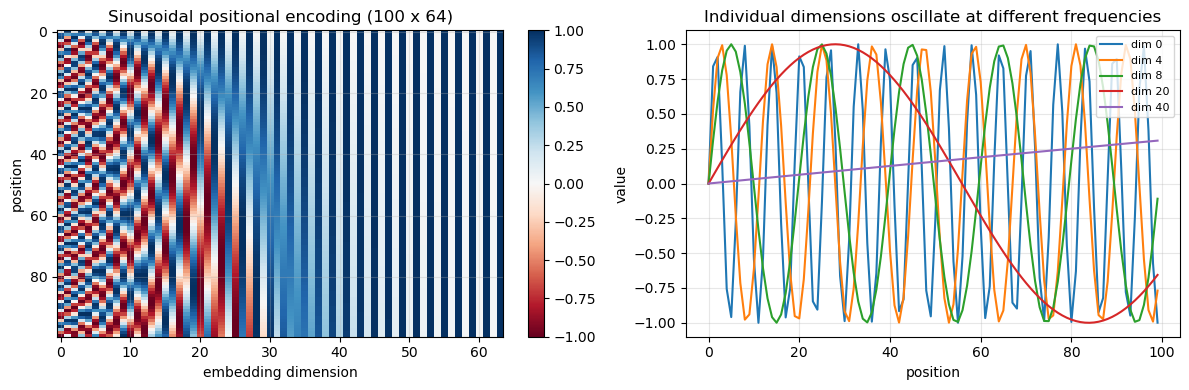

In [9]:
# CHART 3 — the positional-encoding table as a heatmap, plus a few sinusoid columns.
pe_big = np.array(positional_encoding(100, 64))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.0))
im = ax[0].imshow(pe_big, cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
ax[0].set_title("Sinusoidal positional encoding (100 x 64)")
ax[0].set_xlabel("embedding dimension"); ax[0].set_ylabel("position")
fig.colorbar(im, ax=ax[0], fraction=0.046)
for dim in [0, 4, 8, 20, 40]:
    ax[1].plot(pe_big[:, dim], label=f"dim {dim}")
ax[1].set_title("Individual dimensions oscillate at different frequencies")
ax[1].set_xlabel("position"); ax[1].set_ylabel("value"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">Learning note &mdash; Putting it together &mdash; single-head self-attention</h4>
<p style="line-height:180%; font-size:medium;">
You now have every ingredient for a real attention layer. In <i>self</i>-attention the queries, keys, and values all come from the <b>same</b> input <code>x</code>: we project <code>x</code> through three weight matrices <code>Wq</code>, <code>Wk</code>, <code>Wv</code> to obtain <code>q</code>, <code>k</code>, <code>v</code>, build a causal mask sized to the sequence, and run the scaled dot-product attention you already wrote. This single-head layer is the exact unit that the next notebook will replicate into multiple heads and wrap inside a Transformer block, so getting it right here is what unlocks the rest of the lab.
</p>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">4. Single-head self-attention</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Implement <code>self_attention(x, Wq, Wk, Wv)</code> for one sequence <code>x</code> of shape <code>(T, C)</code>. Project <code>x</code> into <code>q = x @ Wq</code>, <code>k = x @ Wk</code>, and <code>v = x @ Wv</code>, build a causal mask of size <code>T</code> with your <code>causal_mask</code>, call <code>scaled_dot_product_attention</code>, and return both the output and the attention matrix. Reuse the two functions you wrote above instead of re-deriving anything.
</p>
</p>

<div style="text-align:center;">
    <img src="images/digikala6.png" style="width:100%;">
</div>

In [10]:
def self_attention(x, Wq, Wk, Wv):
    # Project x into queries (q), keys (k), and values (v)
    q = x @ Wq
    k = x @ Wk
    v = x @ Wv
    
    # Build a causal mask of size T = x.shape[0]
    mask = causal_mask(x.shape[0])
    
    # Run scaled dot-product attention
    out, attn = scaled_dot_product_attention(q, k, v, mask)
    
    return out, attn

In [11]:
# Self-check on a real Shakespeare snippet with fixed random embeddings + weights.
snippet = "To be, or not to be"
ids = jnp.array(encode(snippet))
T = len(snippet)
C = 32
_sk = jax.random.PRNGKey(3)
emb = jax.random.normal(jax.random.fold_in(_sk, 1), (vocab_size, C)) * 0.2
x_demo = emb[ids] + positional_encoding(T, C)
Wq = jax.random.normal(jax.random.fold_in(_sk, 2), (C, C)) * 0.3
Wk = jax.random.normal(jax.random.fold_in(_sk, 3), (C, C)) * 0.3
Wv = jax.random.normal(jax.random.fold_in(_sk, 4), (C, C)) * 0.3

sa_demo_out, sa_demo_attn = self_attention(x_demo, Wq, Wk, Wv)
assert sa_demo_out.shape == (T, C) and sa_demo_attn.shape == (T, T)
assert float(jnp.max(jnp.triu(sa_demo_attn, k=1))) < 1e-6   # still causal
print("OK: self_attention output", sa_demo_out.shape, "| attention", sa_demo_attn.shape)

OK: self_attention output (19, 32) | attention (19, 19)


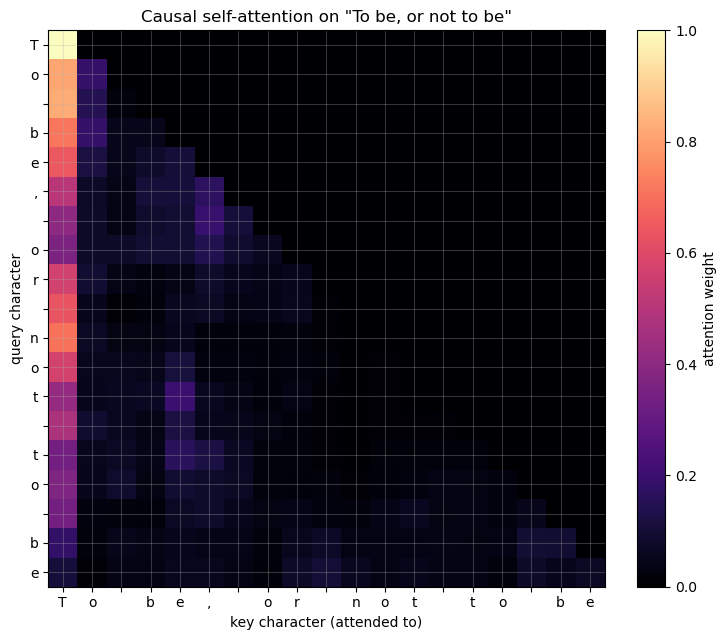

In [12]:
# CHART 4 — attention heatmap on "To be, or not to be" with character tick labels.
labels = [repr(c)[1:-1] for c in snippet]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(np.array(sa_demo_attn), cmap="magma", vmin=0)
ax.set_xticks(range(T)); ax.set_xticklabels(labels)
ax.set_yticks(range(T)); ax.set_yticklabels(labels)
ax.set_title('Causal self-attention on "To be, or not to be"')
ax.set_xlabel("key character (attended to)"); ax.set_ylabel("query character")
fig.colorbar(im, ax=ax, fraction=0.046, label="attention weight")
plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">5. Transformer analysis: attention entropy per query position</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
A useful diagnostic is the <b>entropy</b> of each query's attention distribution. A high entropy means the query spreads its attention over many keys, while a low entropy means it concentrates on a few. Under a causal mask the very first query can only attend to one key, so its entropy must be zero, and later queries have more keys available and therefore the room for higher entropy. We plot the entropy of each row of the attention matrix from the snippet above.
</p>
</p>

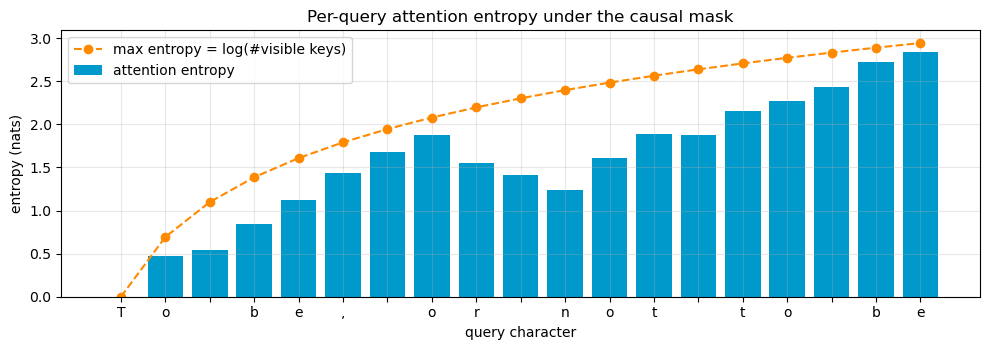

first-query entropy (must be 0): -0.0


In [13]:
# CHART 5 — entropy of each query's attention distribution (causal).
attn_np = np.array(sa_demo_attn)
ent = -np.sum(np.where(attn_np > 0, attn_np * np.log(attn_np + 1e-12), 0.0), axis=-1)
max_ent = np.log(np.arange(1, T + 1))          # max possible entropy given #visible keys
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(range(T), ent, color="#0099cc", label="attention entropy")
ax.plot(range(T), max_ent, "--o", color="#ff8a00", label="max entropy = log(#visible keys)")
ax.set_xticks(range(T)); ax.set_xticklabels(labels)
ax.set_title("Per-query attention entropy under the causal mask")
ax.set_xlabel("query character"); ax.set_ylabel("entropy (nats)"); ax.legend()
plt.tight_layout(); plt.show()
print("first-query entropy (must be 0):", round(float(ent[0]), 6))

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#EF4056">6. Transformer analysis: average attention distance vs position</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
How far back does each position tend to look? For every query we compute the <b>average attention distance</b>, the mean gap <code>i - j</code> between the query position <i>i</i> and the key positions <i>j</i>, weighted by the attention it places on each key. With random untrained weights this curve is mostly a function of how many keys are available, but the same plot on a trained model reveals whether heads specialize into looking nearby or far away. To make the trend smoother we average over a longer random sequence.
</p>
</p>

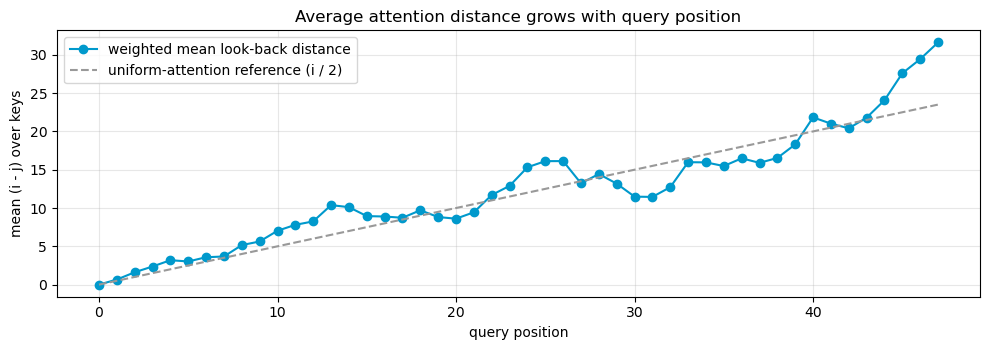

In [14]:
# CHART 6 — average (weighted) attention distance as a function of query position.
Tlong = 48
ids_long = data[1000:1000 + Tlong]
x_long = emb[jnp.asarray(ids_long)] + positional_encoding(Tlong, C)
_, attn_long = self_attention(x_long, Wq, Wk, Wv)
A = np.array(attn_long)
qpos = np.arange(Tlong)[:, None]
kpos = np.arange(Tlong)[None, :]
dist = qpos - kpos                              # >= 0 under the causal mask
avg_dist = np.sum(A * dist, axis=-1)            # weighted mean distance per query

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(range(Tlong), avg_dist, "-o", color="#0099cc", label="weighted mean look-back distance")
ax.plot(range(Tlong), np.arange(Tlong) / 2.0, "--", color="#999",
        label="uniform-attention reference (i / 2)")
ax.set_title("Average attention distance grows with query position")
ax.set_xlabel("query position"); ax.set_ylabel("mean (i - j) over keys"); ax.legend()
plt.tight_layout(); plt.show()